In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# From stored measurements to a bounded conclusion

Chapter 1 · Day 1

Use the actual TinyStories result to practice reading evidence without loading its weights. What is known from the completion record, and what can a fluent opening conceal?

In [2]:
from pathlib import Path
import sys, json
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/dongxi_llms').exists())
sys.path.insert(0, str(ROOT / 'src'))
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(909)
plt.rcParams.update({'figure.figsize': (8, 3.6), 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': False})

In [3]:
e = json.loads((ROOT / 'experiments/reports/2026-09-14-tinystories-learning-result.json').read_text())
print('Exit:', e['process_status']['exit_code'])
print('Updates:', e['completion']['completed_updates'])
print('Minimum sampled host GiB:', e['memory']['minimum_sampled_available_gib'])
print('Final dev NLL:', e['validation_curve'][-1]['loss'])

Exit: 0
Updates: 14000
Minimum sampled host GiB: 104.70319366455078
Final dev NLL: 1.6743147765821944


Prediction: which of these measurements establishes reliable plot coherence? Reference: none directly. Exit checks execution, update count checks the schedule, memory checks a sampled resource criterion, and NLL checks prediction on a fixed target set. A coherence claim must inspect or score complete stories.

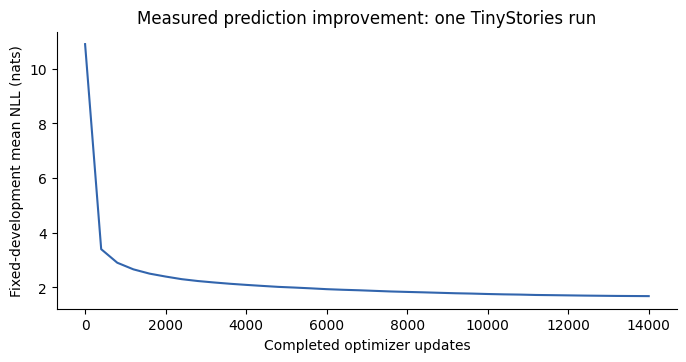

 The rabbit was very happy and loved to hop around. One day, the rabbit saw a big, juicy carrot in the forest. The rabbit wanted to eat the carrot, but it was too high up.
The rabbit asked a wise old owl, "Can you help me get the carrot?" The owl said, "I can help you, but you must be careful and not fall." The rabbit was happy and thanked the owl.
The rabbit hopped around the forest and found a big, juicy carrot. The rabbit was so happy and ate the carrot. But then, a big, mean bear came and tried to take the carrot away. The rabbit was scared and didn't know what to do.
The rabbit said, "I will help you, little rabbit. I will protect you from the big, mean bear." The bear was surprised and said, "I will help you, little rabbit. I will protect you from the big, scary bear." The rabbit was grateful and thanked the bear. From that day on, the rabbit and the bear became good friends and played together in the forest.
EOS emitted: True


In [4]:
points = e['validation_curve']
fig, ax = plt.subplots()
ax.plot([r['update'] for r in points], [r['loss'] for r in points], color='#3265ad')
ax.set(xlabel='Completed optimizer updates', ylabel='Fixed-development mean NLL (nats)',
       title='Measured prediction improvement: one TinyStories run')
plt.show()
final = e['samples'][-1]['samples'][0]
print(final['continuation'])
print('EOS emitted:', final['ended_with_eos'])

**Saved reference preview — rerun the preceding plot cell for current inputs.**

![03 read a real run: reference plot 01](../figures/chapter-01/day-01-03_read_a_real_run-01.png)

This fixed image comes from the CPU reference or the explicitly identified saved evidence; changing inputs does not update the preview automatically.

Reference explanation: the saved curve is measured evidence, not a projected trajectory. The final first-prompt greedy story changes the speaker roles without a consistent explanation, despite ending with EOS. The protocol, sample-selection rule and independent behavioral claim must remain visible together.

Intervention: compare both final decoding methods in `e['samples'][-1]['samples']`. Reference: the sampled story contains additional malformed constructions. Picking only the nicer greedy opening would select evidence by appearance. The archive uses a stated structural checkpoint grid; it does not retain every raw output.

What this proves: the recorded baseline completed, retained a sampled reserve and improved its declared development metric. What remains open: reliable story coherence, memorization audit, replication over training seeds and the controlled trained comparison. The report—not a visually attractive chart—is the durable reference.